**실습(1)-베르누이 분포**  
• 표본 평균, 표본 분산, 이론적 기댓값, 이론적 분산 출력하기  
• 막대 그래프를 사용하여 베르누이 분포 시각화하기

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, bernoulli, binom

np.random.seed(42) #랜덤 결과가 항상 똑같이 나오도록 고정(42는 의미없는 숫자)

In [ ]:
p=0.3 #성공 확률 설정(30%)
n_samples=1000 #실험 반복 횟수

bernoulli_samples=np.random.binomial(1,p,size=n_samples) #이항 분포(n,p): n->시행횟수, p->성공 확률
                                                         #이항 분포에서 시행 횟수 n을 1로 설정하면, 베르누이 분포가 됨

x_bern=np.array([0,1]) #0(실패)과 1(성공)을 배열로 만듦
pmf_bern=bernoulli.pmf(x_bern,p) #각 결과값(0, 1)이 나올 이론적인 확률 계산

In [5]:
sample_mean=np.mean(bernoulli_samples) #생성된 1000개 샘플의 실제 평균(표본평균)을 계산
sample_var=np.var(bernoulli_samples) #생성된 1000개 샘플의 실제 분산(표본분산)을 계산

theoretical_mean=p #이산균등분표의 이론적 기댓값 공식
theoretical_var=p*(1-p) #이산균등분포의 이론적 분산 공식

print(f'성공(1)의 비율(표본평균): {sample_mean:.4f}')
print(f'표본분산: {sample_var:.4f}')
print(f'이론적 기댓값 E(X): {theoretical_mean:.4f}')
print(f'이론적 분산 Var(X): {theoretical_var:.4f}')

성공(1)의 비율(표본평균): 0.2880
표본분산: 0.2051
이론적 기댓값 E(X): 0.3000
이론적 분산 Var(X): 0.2100


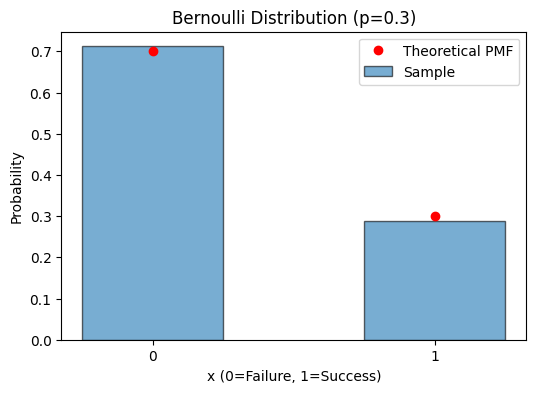

In [ ]:
plt.figure(figsize=(6, 4)) #그래프 크기 설정

values, counts=np.unique(bernoulli_samples, return_counts=True) #value=[0,1]: bernoullit_samples에 담긴 변수
                                                                #return_counts=True(counts 값): 각 변수가 몇 번씩 나왔는지 세기

# 실제 샘플의 히스토그램 그리기
plt.bar(values, counts/n_samples, width=0.5, alpha=0.6, edgecolor='black', label='Sample')

plt.plot(x_bern, pmf_bern, 'ro', label='Theoretical PMF') # 이론적 확률을 빨간 점으로 그리기
plt.xticks([0,1]) #x축 눈금을 0과 1로 명확히 표시
plt.title('Bernoulli Distribution (p=0.3)')
plt.xlabel('x (0=Failure, 1=Success)')
plt.ylabel('Probability')
plt.legend() #범례 표시
plt.show()

**실습 (2)-이항 분포**  
• 표본 평균, 표본 분산, 이론적 기댓값, 이론적 분산 출력하기  
• 히스토그램을 사용하여 이항 분포 시각화하기  
• X가 3일때, 3보다 작거나 같을 때, 7보다 크거나 같을 때의 확률 출력하기  

In [ ]:
n,p=10,0.4
n_samples=1000

binomial_samples=np.random.binomial(n,p,size=n_samples) #이항 분포(n,p): n->시행횟수, p->성공 확률

x_binom=np.arange(0, n+1) #가능한 성공 횟수의 범위(0~n)
pmf_binom=binom.pmf(x_binom, n, p) #각 성공 횟수가 나타날 이론적 확률


In [ ]:
sample_mean=np.mean(binomial_samples) #생성된 1000개 샘플의 실제 평균(표본평균)을 계산
sample_var=np.var(binomial_samples) #생성된 1000개 샘플의 실제 분산(표본분산)을 계산

theoretical_mean=n*p #이항분포의 이론적 기댓값 공식: E(X)=np
theoretical_var=n*p*(1-p) #이산균등분포의 이론적 분산 공식: Var(X)=np(1-p)

print(f'표본평균: {sample_mean:.4f}')
print(f'표본분산: {sample_var:.4f}')
print(f'이론적 기댓값 E(X): {theoretical_mean:.4f}')
print(f'이론적 분산 Var(X): {theoretical_var:.4f}')

표본평균: 4.0090
표본분산: 2.4689
이론적 기댓값 E(X): 4.0000
이론적 분산 Var(X): 2.4000


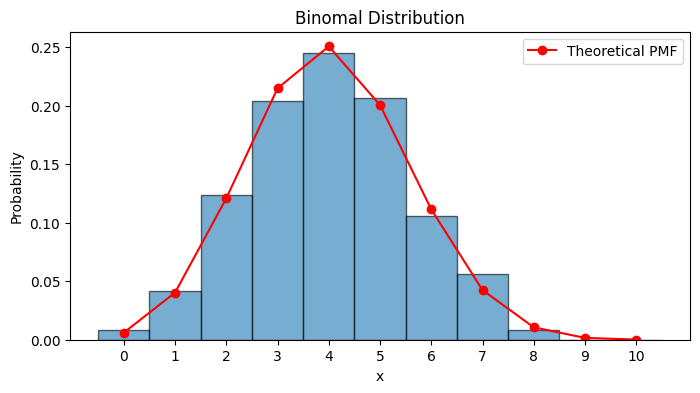

In [ ]:
plt.figure(figsize=(8,4)) #창 크기
plt.hist(binomial_samples, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.6, edgecolor='black') #bins=np.arange(a,b,1): a~b까지 1간격으로 숫자를 만듦
                                                                                                       #density=True: y축을 개수가 아니라 확률(비율)로 변환
                                                                                                       #alpha: 막대의 투명도
plt.plot(x_binom, pmf_binom, 'ro-', label='Theoretical PMF') #ro-: 점과 점 사이를 직선으로 연결
plt.xticks(x_binom) #x축에 1~6에 맞춰 눈금 설정
plt.title('Binomal Distribution')
plt.xlabel('x')
plt.ylabel('Probability')
plt.legend() #범례(Theoretical PMF 등)를 화면에 표시
plt.show()

In [ ]:
print(f'P(X=3)={binom.pmf(3,n,p):.4f}') #pmf(3,n,p): 3번 성공할 확률(Probability Mass Function 확률 질량 함수)
print(f'P(X<=3={binom.cdf(3,n,p):.4f}') #cdf(3,n,p): 3번 이하로 성공할 확률(Cumulative Distribution Function 누적 분포 함수)
print(f'P(X>=7)={1-binom.cdf(6,n,p):.4f}') #1-(6번 이하로 성공할 확률)=7번 이상 성공할 확률

P(X=3)=0.2150
P(X<=3=0.3823
P(X>=7)=0.0548
